--- **TECH CHALLENGE - FASE 4** ---

Este notebook apresenta o desenvolvimento de um modelo de Machine Learning para prever a obesidade. Nosso objetivo é auxiliar médicos e médicas na identificação de pacientes que podem apresentar obesidade, fornecendo uma ferramenta preditiva.

### **Equipe:**
Luis Gustavo Barbosa Ribeiro
Raimar de Assis Modesto

# 1 - Modelagem Dataset Obesity.csv

In [ ]:
#-------------------------------------------------------
#-------------------- INGESTÃO DE DADOS ----------------
#-------------------------------------------------------

import pandas as pd

# Realizamos a ingestão da base de dados 'Obesity.csv' para nosso modelo.
# Esta etapa é crucial para carregar os dados brutos que serão processados e utilizados.
df_obesity = pd.read_csv("/content/sample_data/Obesity.csv")

In [ ]:
#-------------------------------------------------------
#--------------- TRATAMENTO DE DADOS PARA ANÁLISE ------
#-------------------------------------------------------

# Para facilitar a leitura e interpretação dos dados pela equipe médica,
# realizamos o tratamento e a renomeação das colunas do inglês para o português.
df_obesity = df_obesity.rename(columns={
    'Gender': 'GENERO',
    'Age': 'IDADE',
    'Height': 'ALTURA',
    'Weight': 'PESO',
    'family_history': 'HISTORICO_FAMILIAR',
    'Obesity': 'NIVEL_OBESIDADE'
})

#Ajustando Campo GENERO
df_obesity["GENERO"] = df_obesity["GENERO"].replace({
    "Male": "Masculino",
    "Female": "Feminino"
})

#Ajustando Campo HISTORICO_FAMILIAR
df_obesity["HISTORICO_FAMILIAR"] = df_obesity["HISTORICO_FAMILIAR"].replace({
    "yes": "Sim",
    "no": "Não"
})

#Ajustando Campo NIVEL_OBESIDADE
df_obesity["NIVEL_OBESIDADE"] = df_obesity["NIVEL_OBESIDADE"].replace({
    "Insufficient_Weight": "Abaixo do Peso",
    "Normal_Weight": "Peso Adequado",
    "Overweight_Level_I": "Sobrepeso Grau I",
    "Overweight_Level_II": "Sobrepeso Grau II",
    "Obesity_Type_I": "Obesidade Grau I",
    "Obesity_Type_II": "Obesidade Grau II",
    "Obesity_Type_III": "Obesidade Grau III"
})

#Ajustando Campo IDADE
df_obesity["IDADE"] = df_obesity["IDADE"].astype(int)

#Ajustando Campo ALTURA
df_obesity["ALTURA"] = df_obesity["ALTURA"].round(2)

#Ajustando Campo PESO
df_obesity["PESO"] = df_obesity["PESO"].round(1)

#Ajustando Campo FAVC
df_obesity["FAVC"] = df_obesity["FAVC"].replace({
    "yes": "Sim",
    "no": "Não"
})

#Ajustando Campo SMOKE
df_obesity["SMOKE"] = df_obesity["SMOKE"].replace({
    "yes": "Sim",
    "no": "Não"
})

#Ajustando Campo SCC
df_obesity["SCC"] = df_obesity["SCC"].replace({
    "yes": "Sim",
    "no": "Não"
})

#FCVC - Consumo de vegetais
df_obesity["FCVC"] = df_obesity["FCVC"].round().astype(int)

df_obesity["FCVC_DESC"] = df_obesity["FCVC"].replace({
    1: "Raramente",
    2: "Às vezes",
    3: "Sempre"
})

#NCP - Refeições principais por dia
df_obesity["NCP"] = df_obesity["NCP"].round().astype(int)

df_obesity["NCP_DESC"] = df_obesity["NCP"].replace({
    1: "Uma refeição",
    2: "Duas refeições",
    3: "Três refeições",
    4: "Quatro ou mais refeições"
})

#CH2O - Consumo de água
df_obesity["CH2O"] = df_obesity["CH2O"].round().astype(int)

df_obesity["CH2O_DESC"] = df_obesity["CH2O"].replace({
    1: "Menos de 1 litro",
    2: "Entre 1 e 2 litros",
    3: "Mais de 2 litros"
})

#FAF - Atividade física
df_obesity["FAF"] = df_obesity["FAF"].round().astype(int)

df_obesity["FAF_DESC"] = df_obesity["FAF"].replace({
    0: "Nenhuma",
    1: "1 a 2 vezes por semana",
    2: "3 a 4 vezes por semana",
    3: "5 vezes ou mais por semana"
})

#TUE - Tempo de dispositivos eletrônicos
df_obesity["TUE"] = df_obesity["TUE"].round().astype(int)

df_obesity["TUE_DESC"] = df_obesity["TUE"].replace({
    0: "0 a 2 horas",
    1: "3 a 5 horas",
    2: "Mais de 5 horas"
})

#CAEC
df_obesity["CAEC"] = df_obesity["CAEC"].replace({
    "no": "Não",
    "Sometimes": "Às vezes",
    "Frequently": "Frequentemente",
    "Always": "Sempre"
})

#CALC
df_obesity["CALC"] = df_obesity["CALC"].replace({
    "no": "Não",
    "Sometimes": "Às vezes",
    "Frequently": "Frequentemente",
    "Always": "Sempre"
})

#MTRANS
df_obesity["MTRANS"] = df_obesity["MTRANS"].replace({
    "Public_Transportation": "Transporte Público",
    "Walking": "Caminhada",
    "Automobile": "Automóvel",
    "Motorbike": "Motocicleta",
    "Bike": "Bicicleta"
})

#Removendo duplicidades
# df_obesity = df_obesity.drop_duplicates()

In [ ]:
#-------------------------------------------------------
#--------------- PREPARAÇÃO DA BASE PARA MODELO --------
#-------------------------------------------------------

# Criamos uma cópia do dataframe original para prepará-lo especificamente para o modelo de Machine Learning.
df_model = df_obesity.copy()

# Convertemos a variável 'GENERO' para um formato binário (0 e 1),
# que é adequado para o treinamento do modelo.
df_model["GENERO_BIN"] = df_model["GENERO"].replace({
    "Feminino": 0,
    "Masculino": 1
})

# Convertemos a variável 'HISTORICO_FAMILIAR' para um formato binário.
df_model["HISTORICO_FAMILIAR_BIN"] = df_model["HISTORICO_FAMILIAR"].replace({
    "Não": 0,
    "Sim": 1
})

# Convertemos a variável 'FAVC' (consumo de alimentos altamente calóricos) para um formato binário.
df_model["FAVC_BIN"] = df_model["FAVC"].replace({
    "Não": 0,
    "Sim": 1
})

# Convertemos a variável 'SMOKE' (tabagismo) para um formato binário.
df_model["SMOKE_BIN"] = df_model["SMOKE"].replace({
    "Não": 0,
    "Sim": 1
})

# Convertemos a variável 'SCC' (monitoramento do consumo de calorias) para um formato binário.
df_model["SCC_BIN"] = df_model["SCC"].replace({
    "Não": 0,
    "Sim": 1
})

# Atribuímos pontuações numéricas à variável categórica 'CAEC' (consumo de alimentos entre as refeições).
df_model["CAEC_SCORE"] = df_model["CAEC"].replace({
    "Não": 0,
    "Às vezes": 1,
    "Frequentemente": 2,
    "Sempre": 3
})

# Atribuímos pontuações numéricas à variável categórica 'CALC' (consumo de álcool).
df_model["CALC_SCORE"] = df_model["CALC"].replace({
    "Não": 0,
    "Às vezes": 1,
    "Frequentemente": 2,
    "Sempre": 3
})

# Criamos uma nova feature, o Índice de Massa Corporal (IMC), a partir das variáveis 'PESO' e 'ALTURA'.
# O IMC é um indicador fundamental na avaliação da obesidade.
df_model["IMC"] = (
    df_model["PESO"] /
    (df_model["ALTURA"] ** 2)
)

# Convertemos a variável categórica 'MTRANS' (meio de transporte) em variáveis dummy (binárias).
# Isso é feito para que o modelo possa interpretar esses dados.
df_model = pd.get_dummies(
    df_model,
    columns=["MTRANS"],
    prefix="MTRANS",
    drop_first=True # Evitamos a multicolinearidade removendo uma das categorias
)

# Visualizamos as primeiras linhas da base de dados preparada para modelagem para verificar as transformações.
# display(df_model.head())

# Conferimos as colunas criadas e as features resultantes para o modelo.
# df_model.columns

/tmp/ipykernel_1377/2511944662.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model["GENERO_BIN"] = df_model["GENERO"].replace({
/tmp/ipykernel_1377/2511944662.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model["HISTORICO_FAMILIAR_BIN"] = df_model["HISTORICO_FAMILIAR"].replace({
/tmp/ipykernel_1377/2511944662.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to t

# 2 - Análise Exploratória

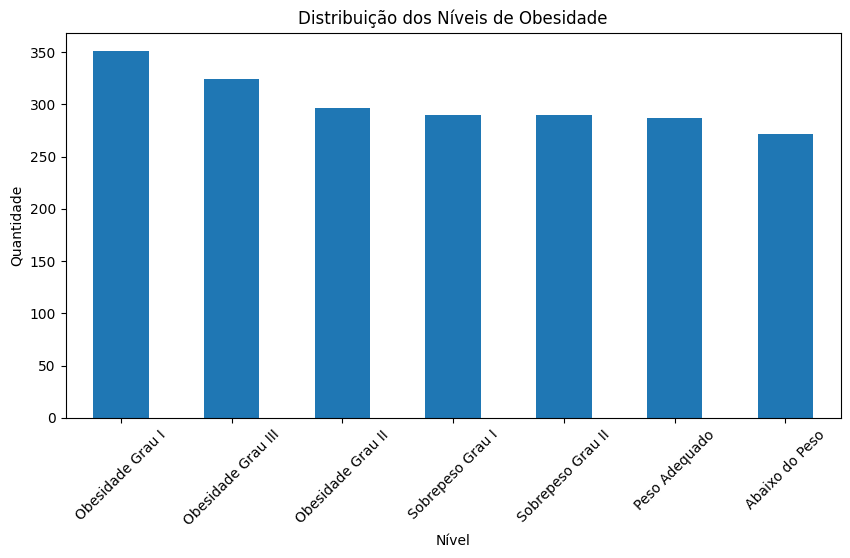

In [ ]:
#-------------------------------------------------------
#--------- ANÁLISE EXPLORATÓRIA - DISTRIBUIÇÃO DO NÍVEL DE OBESIDADE --
#-------------------------------------------------------

# Importamos a biblioteca matplotlib para visualização de dados.
import matplotlib.pyplot as plt

# Definimos o tamanho da figura para melhor visualização.
plt.figure(figsize=(10,5))

# Criamos um gráfico de barras para mostrar a distribuição dos diferentes níveis de obesidade na nossa base.
# Isso nos ajuda a entender a proporção de cada categoria.
df_obesity["NIVEL_OBESIDADE"].value_counts().plot(
    kind="bar"
)

# Adicionamos um título significativo ao gráfico.
plt.title("Distribuição dos Níveis de Obesidade")
# Rotulamos o eixo X como 'Nível'.
plt.xlabel("Nível")
# Rotulamos o eixo Y como 'Quantidade'.
plt.ylabel("Quantidade")
# Rotacionamos os rótulos do eixo X para melhor legibilidade.
plt.xticks(rotation=45)

# Exibimos o gráfico.
plt.show()

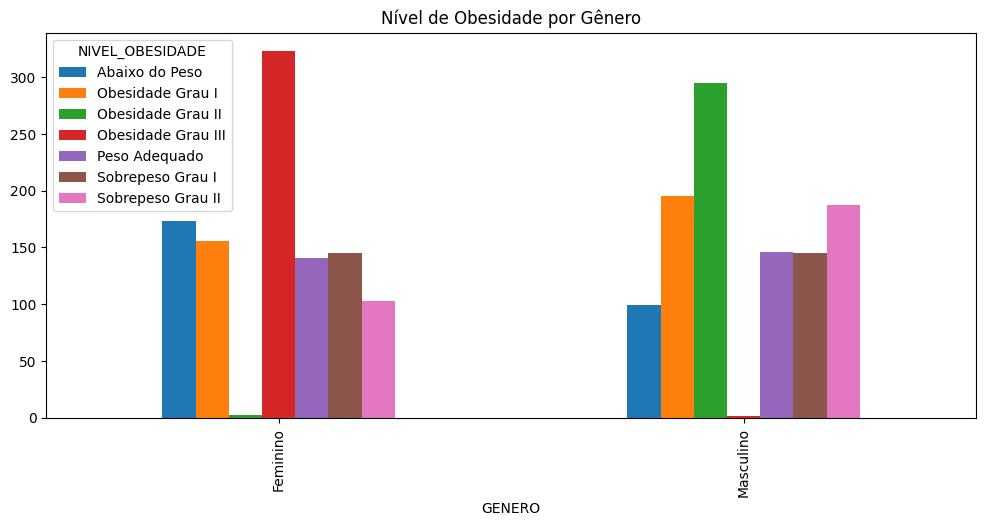

In [ ]:
#-------------------------------------------------------
#--------- ANÁLISE EXPLORATÓRIA - OBESIDADE POR GÊNERO --
#-------------------------------------------------------

# Utilizamos `pd.crosstab` para criar uma tabela de contingência
# que nos mostra a frequência de cada nível de obesidade por gênero.
pd.crosstab(
    df_obesity["GENERO"],
    df_obesity["NIVEL_OBESIDADE"]
)

# Geramos um gráfico de barras a partir da tabela de contingência
# para visualizar a relação entre gênero e nível de obesidade.
pd.crosstab(
    df_obesity["GENERO"],
    df_obesity["NIVEL_OBESIDADE"]
).plot(
    kind="bar",
    figsize=(12,5)
)

# Adicionamos um título descritivo ao gráfico.
plt.title("Nível de Obesidade por Gênero")
# Exibimos o gráfico.
plt.show()

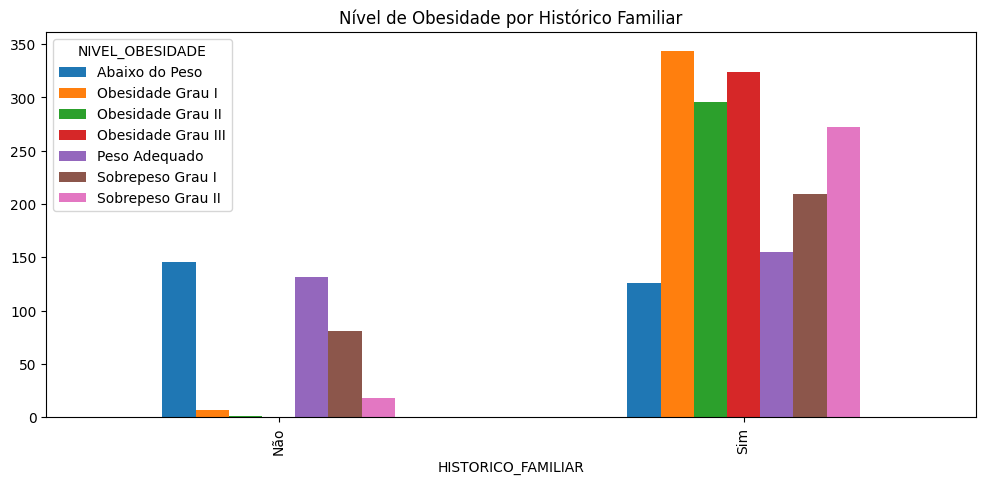

In [ ]:
#-------------------------------------------------------
#--------- ANÁLISE EXPLORATÓRIA - OBESIDADE POR HISTÓRICO FAMILIAR --
#-------------------------------------------------------

# Criamos uma tabela de contingência para analisar a relação entre
# o histórico familiar de obesidade e os níveis de obesidade atuais.
pd.crosstab(
    df_obesity["HISTORICO_FAMILIAR"],
    df_obesity["NIVEL_OBESIDADE"]
)

# Visualizamos essa relação através de um gráfico de barras.
# Isso nos ajuda a identificar se há uma correlação entre histórico familiar e obesidade.
pd.crosstab(
    df_obesity["HISTORICO_FAMILIAR"],
    df_obesity["NIVEL_OBESIDADE"]
).plot(
    kind="bar",
    figsize=(12,5)
)

# Adicionamos um título claro ao gráfico.
plt.title("Nível de Obesidade por Histórico Familiar")
# Exibimos o gráfico.
plt.show()

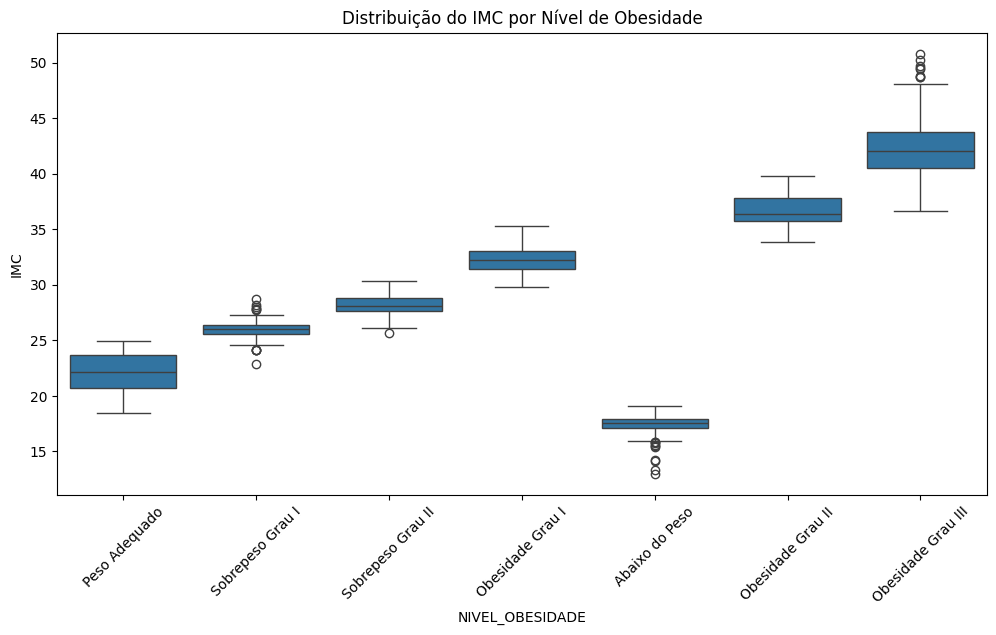

In [ ]:
#-------------------------------------------------------
#--------- ANÁLISE EXPLORATÓRIA - IMC POR NÍVEL DE OBESIDADE --
#-------------------------------------------------------

# Importamos a biblioteca seaborn, que é excelente para visualizações estatísticas.
import seaborn as sns

# Definimos o tamanho da figura para o gráfico.
plt.figure(figsize=(12,6))

# Utilizamos um boxplot para visualizar a distribuição do IMC para cada nível de obesidade.
# Isso nos permite observar a mediana, quartis e possíveis outliers para cada categoria.
sns.boxplot(
    data=df_model,
    x="NIVEL_OBESIDADE",
    y="IMC"
)

# Rotacionamos os rótulos do eixo X para melhor legibilidade, dado o número de categorias.
plt.xticks(rotation=45)
# Adicionamos um título que descreve o conteúdo do gráfico.
plt.title("Distribuição do IMC por Nível de Obesidade")

# Exibimos o gráfico.
plt.show()

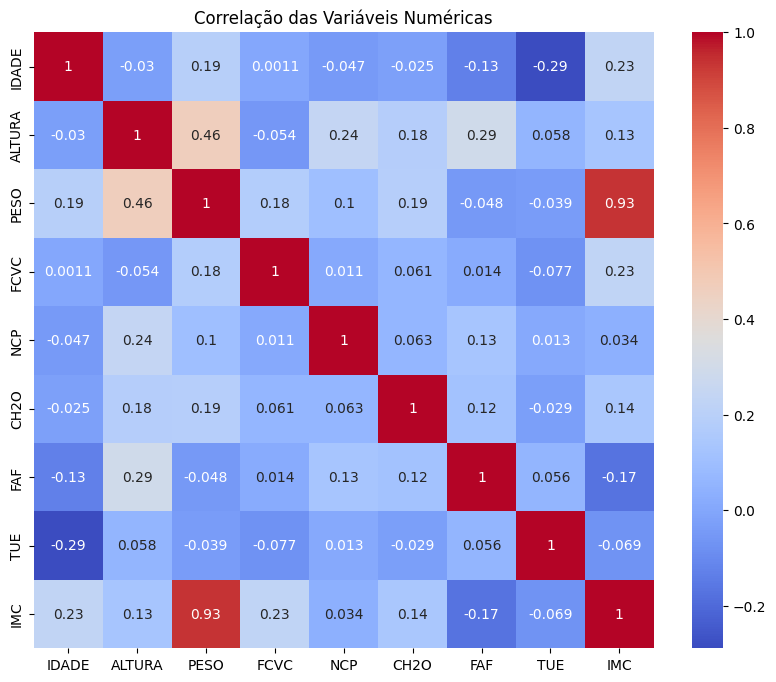

In [ ]:
#-------------------------------------------------------
#--------- ANÁLISE EXPLORATÓRIA - CORRELAÇÃO DAS VARIÁVEIS NUMÉRICAS --
#-------------------------------------------------------

# Importamos a biblioteca seaborn para criar o mapa de calor.
import seaborn as sns

# Selecionamos as variáveis numéricas que queremos analisar a correlação.
numericas = [
    "IDADE",
    "ALTURA",
    "PESO",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "IMC"
]

# Definimos o tamanho da figura para o mapa de calor.
plt.figure(figsize=(10,8))

# Criamos um mapa de calor (heatmap) para visualizar a matriz de correlação das variáveis numéricas.
# O `annot=True` exibe os valores de correlação nas células.
# `cmap="coolwarm"` define o esquema de cores, onde cores quentes indicam correlação positiva e frias negativa.
sns.heatmap(
    df_model[numericas].corr(),
    annot=True,
    cmap="coolwarm"
)

# Adicionamos um título explicativo ao mapa de calor.
plt.title("Correlação das Variáveis Numéricas")

# Exibimos o mapa de calor.
plt.show()

# 3 - Treinamento Modelo

In [ ]:
#-------------------------------------------------------
#--------- CRIAÇÃO DA VARIÁVEL ALVO NUMÉRICA ------------
#-------------------------------------------------------

# Importamos LabelEncoder do sklearn.preprocessing para transformar variáveis categóricas em numéricas.
from sklearn.preprocessing import LabelEncoder

# Instanciamos o LabelEncoder.
le_target = LabelEncoder()

# Aplicamos o LabelEncoder na coluna 'NIVEL_OBESIDADE' para criar a variável alvo numérica 'TARGET'.
# Esta variável será utilizada no treinamento do modelo.
df_model["TARGET"] = le_target.fit_transform(
    df_model["NIVEL_OBESIDADE"]
)

# Exibimos as primeiras linhas das colunas 'NIVEL_OBESIDADE' e 'TARGET'
# para verificar a transformação realizada.
df_model[["NIVEL_OBESIDADE","TARGET"]].head()

,NIVEL_OBESIDADE,TARGET
0,Peso Adequado,4
1,Peso Adequado,4
2,Peso Adequado,4
3,Sobrepeso Grau I,5
4,Sobrepeso Grau II,6


In [ ]:
#-------------------------------------------------------
#--------------- TREINAMENTO DO MODELO -----------------
#-------------------------------------------------------

# Importamos as bibliotecas necessárias para o treinamento e avaliação do modelo.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Recriamos o encoder da variável alvo para garantir que esteja consistente com o treinamento.
le_target = LabelEncoder()
df_model["TARGET"] = le_target.fit_transform(df_model["NIVEL_OBESIDADE"])

# Definimos as variáveis explicativas (features) que serão utilizadas no modelo.
# Escolhemos as colunas que consideramos relevantes para a previsão da obesidade.
features = [
    "IDADE",
    "ALTURA",
    "PESO",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "IMC",
    "GENERO_BIN",
    "HISTORICO_FAMILIAR_BIN",
    "FAVC_BIN",
    "SMOKE_BIN",
    "SCC_BIN",
    "CAEC_SCORE",
    "CALC_SCORE"
]

# Incluímos automaticamente as colunas criadas a partir da variável 'MTRANS' (transporte).
# Isso garante que todas as variáveis dummy de transporte sejam consideradas.
features_mtrans = [col for col in df_model.columns if col.startswith("MTRANS_")]
features = features + features_mtrans

# Separamos os dados em variáveis explicativas (X) e variável alvo (y).
X = df_model[features]
y = df_model["TARGET"]

# Dividimos os dados em conjuntos de treinamento e teste.
# `test_size=0.2` indica que 20% dos dados serão usados para teste.
# `random_state=42` garante a reprodutibilidade dos resultados.
# `stratify=y` assegura que a proporção das classes da variável alvo seja mantida em ambos os conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Criamos uma instância do modelo RandomForestClassifier.
# `n_estimators=300` define o número de árvores na floresta.
# `random_state=42` garante a reprodutibilidade.
# `max_depth=None` permite que as árvores se expandam totalmente.
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

# Treinamos o modelo utilizando os dados de treinamento (X_train, y_train).
modelo_rf.fit(X_train, y_train)

# Realizamos previsões no conjunto de teste (X_test).
y_pred = modelo_rf.predict(X_test)

# Calculamos e exibimos a acurácia do modelo.
# A acurácia nos informa a proporção de previsões corretas.
acuracia = accuracy_score(y_test, y_pred)
print("Acurácia do modelo:", round(acuracia * 100, 2), "%")

# Geramos e exibimos o relatório de classificação, que inclui precisão, recall e f1-score
# para cada classe e médias ponderadas.
print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le_target.classes_
))

Acurácia do modelo: 98.82 %

Relatório de classificação:
                    precision    recall  f1-score   support

    Abaixo do Peso       1.00      0.98      0.99        54
  Obesidade Grau I       1.00      1.00      1.00        70
 Obesidade Grau II       1.00      1.00      1.00        60
Obesidade Grau III       1.00      1.00      1.00        65
     Peso Adequado       0.97      0.97      0.97        58
  Sobrepeso Grau I       0.95      0.98      0.97        58
 Sobrepeso Grau II       1.00      0.98      0.99        58

          accuracy                           0.99       423
         macro avg       0.99      0.99      0.99       423
      weighted avg       0.99      0.99      0.99       423



# 4 - Avaliação do Modelo

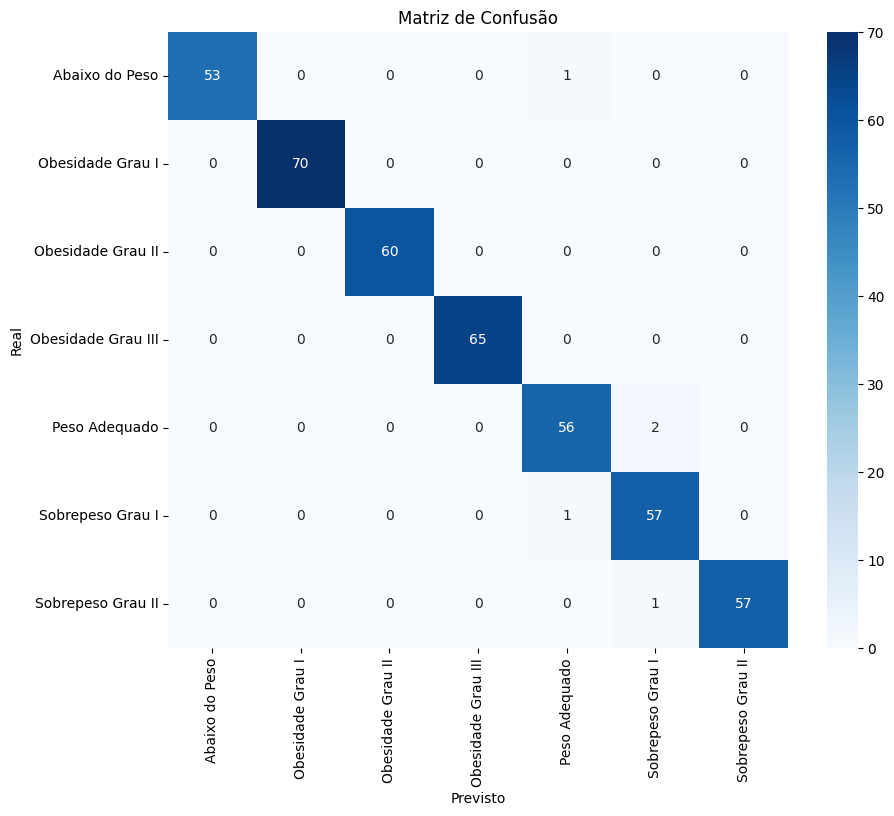

In [ ]:
#-------------------------------------------------------
#--------------- AVALIAÇÃO DO MODELO - MATRIZ DE CONFUSÃO --
#-------------------------------------------------------

# Importamos as bibliotecas necessárias para criar a matriz de confusão e visualizá-la.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos a matriz de confusão comparando os valores reais (y_test) com os previstos (y_pred).
cm = confusion_matrix(y_test, y_pred)

# Definimos o tamanho da figura para a visualização da matriz.
plt.figure(figsize=(10,8))

# Criamos um mapa de calor da matriz de confusão usando seaborn.
# `annot=True` exibe os números dentro das células.
# `fmt='d'` formata os números como inteiros.
# `cmap='Blues'` define o esquema de cores.
# `xticklabels` e `yticklabels` são os nomes das classes para os eixos, facilitando a interpretação.
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

# Adicionamos um título descritivo ao gráfico.
plt.title("Matriz de Confusão")
# Rotulamos o eixo X como 'Previsto'.
plt.xlabel("Previsto")
# Rotulamos o eixo Y como 'Real'.
plt.ylabel("Real")

# Exibimos o gráfico da matriz de confusão.
plt.show()

In [ ]:
#-------------------------------------------------------
#--------------- AVALIAÇÃO DO MODELO - IMPORTÂNCIA DAS VARIÁVEIS --
#-------------------------------------------------------

# Importamos a biblioteca pandas para manipulação de dados.
import pandas as pd

# Criamos um DataFrame para armazenar a importância de cada variável no modelo.
# A importância é obtida do atributo `feature_importances_` do modelo Random Forest.
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

# Ordenamos as variáveis pela sua importância em ordem decrescente.
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

# Exibimos as 15 variáveis mais importantes para o modelo.
# Isso nos ajuda a entender quais fatores mais influenciam a previsão de obesidade.
display(importancias.head(15))

,Variavel,Importancia
8,IMC,0.394044
2,PESO,0.217779
1,ALTURA,0.062166
0,IDADE,0.060950
9,GENERO_BIN,0.057823
3,FCVC,0.028905
14,CAEC_SCORE,0.027382
15,CALC_SCORE,0.023734
10,HISTORICO_FAMILIAR_BIN,0.022571
4,NCP,0.022563


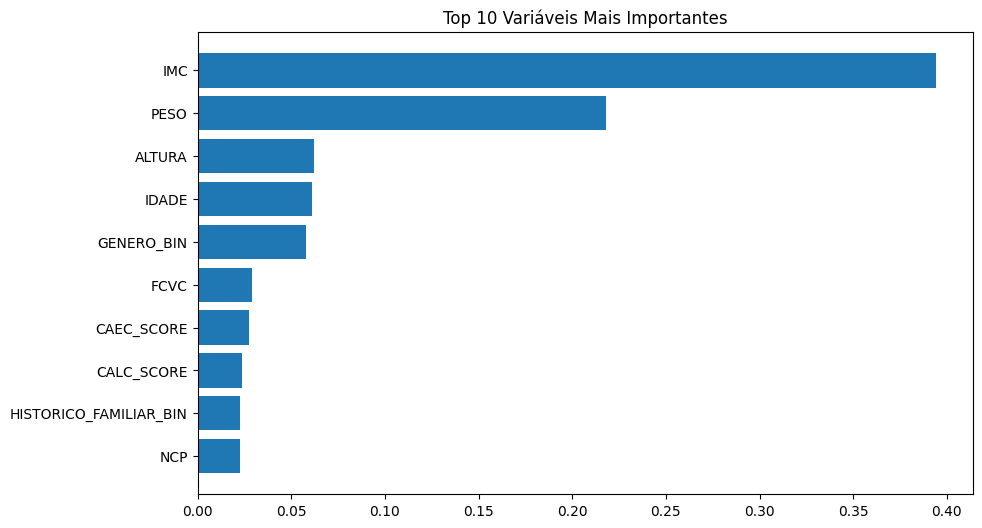

In [ ]:
#-------------------------------------------------------
#--------------- AVALIAÇÃO DO MODELO - GRÁFICO DE IMPORTÂNCIA DAS VARIÁVEIS --
#-------------------------------------------------------

# Importamos a biblioteca matplotlib para visualização de dados.
import matplotlib.pyplot as plt

# Definimos o tamanho da figura para o gráfico.
plt.figure(figsize=(10,6))

# Criamos um gráfico de barras horizontais para visualizar as 10 variáveis mais importantes.
# Isso proporciona uma representação visual clara de quais características têm maior peso no modelo.
plt.barh(
    importancias["Variavel"][:10],
    importancias["Importancia"][:10]
)

# Adicionamos um título descritivo ao gráfico.
plt.title("Top 10 Variáveis Mais Importantes")

# Invertemos o eixo Y para que a variável mais importante apareça no topo do gráfico.
plt.gca().invert_yaxis()

# Exibimos o gráfico.
plt.show()

# 5 - Exportação do Modelo

In [ ]:
#-------------------------------------------------------
#---------------- EXPORTAÇÃO DO MODELO -----------------
#-------------------------------------------------------

# Importamos a biblioteca joblib para salvar e carregar modelos Python de forma eficiente.
import joblib

# Salvamos o modelo treinado (Random Forest) em um arquivo .pkl.
# Este arquivo pode ser carregado posteriormente para fazer novas previsões sem a necessidade de retreinar o modelo.
joblib.dump(
    modelo_rf,
    "modelo_obesidade.pkl"
)

# Salvamos o LabelEncoder em um arquivo .pkl.
# É fundamental salvar o encoder junto com o modelo para garantir que as novas entradas
# e as saídas do modelo sejam codificadas da mesma forma que durante o treinamento.
joblib.dump(
    le_target,
    "encoder_obesidade.pkl"
)

print("Arquivos exportados com sucesso!")

Arquivos exportados com sucesso!


In [ ]:
#-------------------------------------------------------
#--------- EXPORTAÇÃO DA LISTA DE FEATURES -------------
#-------------------------------------------------------

# Importamos a biblioteca joblib para salvar a lista de features.
import joblib

# Salvamos a lista de variáveis (features) utilizadas no treinamento do modelo em um arquivo .pkl.
# Isso é importante para garantir que, ao carregar o modelo para inferência,
# as novas entradas de dados tenham exatamente as mesmas colunas e na mesma ordem.
joblib.dump(
    features,
    "features_modelo.pkl"
)

print("Lista de features exportada com sucesso!")

Lista de features exportada com sucesso!


# 6 - Aplicação Preditiva com Streamlit

In [ ]:
from google.colab import files

files.download("modelo_obesidade.pkl")
files.download("encoder_obesidade.pkl")
files.download("features_modelo.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Os arquivos do modelo (`modelo_obesidade.pkl`), do codificador de classes (`encoder_obesidade.pkl`) e da lista de features (`features_modelo.pkl`) são baixados para serem utilizados em uma aplicação externa, como um aplicativo Streamlit. Esta etapa é fundamental para implantar o modelo treinado e permitir que ele faça previsões em um ambiente de produção ou em uma interface de usuário interativa.